In [ ]:
# Cell 0: Imports + device

import os, glob, json, math, pickle, random, shutil, time
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


DEVICE: cuda
GPU: Tesla T4


In [ ]:
# Cell 1: Mount Drive

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cell 2: Paths

DATASET_PATH = "/content/drive/MyDrive/AIAGENT_FINAL/obtain_diamond_v3_fixdone"
SEQ_DIR      = "/content/drive/MyDrive/AIAGENT_FINAL/outputs_sequences"
SWEEP_ROOT   = "/content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep"
REPAIR_ROOT  = "/content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/alignment_repair"
METRICS_DIR  = "/content/drive/MyDrive/AIAGENT_FINAL/outputs/metrics"
os.makedirs(REPAIR_ROOT, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

EXPERIMENT_INDEX_PATH = os.path.join(SWEEP_ROOT, "experiment_index.json")
ROLL_RESULTS_PATH     = os.path.join(METRICS_DIR, "rollout_results.json")
ACTION_BANK_PATH      = os.path.join(METRICS_DIR, "candidate_action_bank.npz")
REPAIR_RESULTS_PATH   = os.path.join(METRICS_DIR, "alignment_repair.json")

train_pkl = os.path.join(SEQ_DIR, "train_sequences.pkl")
val_pkl   = os.path.join(SEQ_DIR, "val_sequences.pkl")
test_pkl  = os.path.join(SEQ_DIR, "test_sequences.pkl")
meta_json = os.path.join(SEQ_DIR, "sequences_meta.json")
norm_path = os.path.join(SEQ_DIR, "global_train_state_norm_stats.npz")

with open(train_pkl, "rb") as f:
    train_seqs = pickle.load(f)
with open(val_pkl, "rb") as f:
    val_seqs = pickle.load(f)
with open(test_pkl, "rb") as f:
    test_seqs = pickle.load(f)
with open(meta_json, "r") as f:
    seq_meta = json.load(f)
with open(EXPERIMENT_INDEX_PATH, "r") as f:
    experiment_index = json.load(f)

z = np.load(norm_path)
state_mean = z["state_mean"].astype(np.float32)
state_std  = z["state_std"].astype(np.float32)

SEQ_LEN = int(seq_meta["seq_len"])
BURN_IN = int(seq_meta["burn_in"])

print("Loaded train/val/test sequences:", len(train_seqs), len(val_seqs), len(test_seqs))
print("Num sweep runs:", len(experiment_index["runs"]))

Loaded train/val/test sequences: 200000 150952 149650
Num sweep runs: 15


In [ ]:
import shutil, os
if os.path.exists(REPAIR_ROOT):
    shutil.rmtree(REPAIR_ROOT)
os.makedirs(REPAIR_ROOT, exist_ok=True)
print("Reset repair directory:", REPAIR_ROOT)

Reset repair directory: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/alignment_repair


In [ ]:
# Cell 3: Experiment config

SOURCE_ALPHA = 0.00
SEEDS = [1337, 1338, 1339]

# NEW: calibration sizes by sequence count, not shard count
CALIB_SEQ_COUNTS = [0, 2000, 5000, 10000]

# NEW: multiple calibration subset replicates per size
CALIB_REPLICATES = 3

# fine-tuning config
REPAIR_MAX_STEPS = 2000          # reduced from 4000
REPAIR_EVAL_EVERY = 250
REPAIR_LOG_EVERY = 50
REPAIR_EARLY_STOP_PATIENCE = 6
REPAIR_LR = 5e-5                 # reduced from 1e-4
REPAIR_BATCH_SIZE = 32
REPAIR_GRAD_CLIP = 100.0
SKIP_EXISTING = True

# evaluation config
HORIZONS = [1, 2, 5, 10, 20]
STEP_OFFSET = 0
TEST_CAP = None
BATCH_SIZE_EVAL = 128 if DEVICE.type == "cuda" else 32
NUM_WORKERS = 0
SEED_EVAL = 2028

# action-agreement proxy config
CANDIDATE_K = 16
PLAN_HORIZON = 5

print("SOURCE_ALPHA:", SOURCE_ALPHA)
print("CALIB_SEQ_COUNTS:", CALIB_SEQ_COUNTS)
print("CALIB_REPLICATES:", CALIB_REPLICATES)
print("REPAIR_MAX_STEPS:", REPAIR_MAX_STEPS)
print("REPAIR_LR:", REPAIR_LR)
print("PLAN_HORIZON:", PLAN_HORIZON)

SOURCE_ALPHA: 0.0
CALIB_SEQ_COUNTS: [0, 2000, 5000, 10000]
CALIB_REPLICATES: 3
REPAIR_MAX_STEPS: 2000
REPAIR_LR: 5e-05
PLAN_HORIZON: 5


In [ ]:
# Cell 4: Shard paths

shards = sorted(glob.glob(os.path.join(DATASET_PATH, "shard_*.npz")))
path_map = {os.path.basename(p): p for p in shards}
assert len(path_map) == 30, f"Expected 30 shards, got {len(path_map)}"

def check_seq_refs(seqs, name):
    names = {s["shard"] for s in seqs}
    missing = sorted(list(names - set(path_map.keys())))
    assert len(missing) == 0, f"{name} references missing shards: {missing[:5]}"

check_seq_refs(train_seqs, "train")
check_seq_refs(val_seqs, "val")
check_seq_refs(test_seqs, "test")
print("Shard references OK.")

Shard references OK.


In [ ]:
# Cell 5: Shared normalized shard cache

_SHARD_CACHE = {}

def load_shard_cached(shard_name: str):
    if shard_name in _SHARD_CACHE:
        return _SHARD_CACHE[shard_name]

    p = path_map[shard_name]
    with np.load(p) as d:
        obs = d["obs"].astype(np.float32)
        mainhand = d["mainhand"].astype(np.float32)
        action = d["action"].astype(np.float32)
        reward = d["reward"].astype(np.float32)
        done = d["done"].astype(np.bool_)

    state_raw = np.concatenate([obs, mainhand], axis=1)
    state = (state_raw - state_mean) / (state_std + 1e-8)

    _SHARD_CACHE[shard_name] = (state, action, reward, done)
    return _SHARD_CACHE[shard_name]

In [ ]:
# Cell 6: Dataset / loader

class SequenceDataset(Dataset):
    def __init__(self, seqs, seq_len=50):
        self.seqs = seqs
        self.L = seq_len

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        rec = self.seqs[idx]
        shard = rec["shard"]
        t0 = int(rec["t0"])
        L  = int(rec["length"])
        assert L == self.L

        state, action, reward, done = load_shard_cached(shard)

        s = state[t0:t0+L+1]
        a = action[t0:t0+L]
        r = reward[t0:t0+L]
        cont = 1.0 - done[t0:t0+L].astype(np.float32)

        return (
            torch.from_numpy(s),
            torch.from_numpy(a),
            torch.from_numpy(r),
            torch.from_numpy(cont),
        )

def make_loader(seqs, batch_size, shuffle=False, cap=None, seed=0, drop_last=False):
    if cap is not None and len(seqs) > cap:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(seqs), size=cap, replace=False)
        idx = np.sort(idx)
        seqs = [seqs[i] for i in idx]

    ds = SequenceDataset(seqs, seq_len=SEQ_LEN)
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=drop_last,
    )
    return dl, len(ds)

def filter_sequences_by_shards(seq_list, shard_set):
    shard_set = set(shard_set)
    return [rec for rec in seq_list if rec["shard"] in shard_set]

In [ ]:
# Cell 7: RSSM model definitions

def _init_layer(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

class Encoder(nn.Module):
    def __init__(self, state_dim=28, hidden=256, embed_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, embed_dim), nn.ReLU(),
        )
        self.apply(_init_layer)

    def forward(self, s):
        return self.net(s)

class RSSM(nn.Module):
    def __init__(self, action_dim=15, deter_dim=256, stoch_dim=32, hidden=256, min_std=0.1):
        super().__init__()
        self.deter_dim = deter_dim
        self.stoch_dim = stoch_dim
        self.min_std = min_std

        self.gru = nn.GRUCell(stoch_dim + action_dim, deter_dim)

        self.prior_net = nn.Sequential(
            nn.Linear(deter_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, 2 * stoch_dim),
        )

        self.post_net = nn.Sequential(
            nn.Linear(deter_dim + hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2 * stoch_dim),
        )
        self.apply(_init_layer)

    def init_state(self, batch_size):
        h = torch.zeros(batch_size, self.deter_dim, device=DEVICE)
        z = torch.zeros(batch_size, self.stoch_dim, device=DEVICE)
        return h, z

    def _dist(self, params):
        mu, std = torch.chunk(params, 2, dim=-1)
        std = F.softplus(std) + self.min_std
        return mu, std

    def deter_step(self, h, z, a):
        x = torch.cat([z, a], dim=-1)
        h = self.gru(x, h)
        return h

    def prior(self, h):
        params = self.prior_net(h)
        mu, std = self._dist(params)
        return mu, std

    def posterior(self, h, embed):
        x = torch.cat([h, embed], dim=-1)
        params = self.post_net(x)
        mu, std = self._dist(params)
        return mu, std

    def sample(self, mu, std):
        eps = torch.randn_like(mu)
        return mu + eps * std

class Decoder(nn.Module):
    def __init__(self, deter_dim=256, stoch_dim=32, hidden=256, state_dim=28):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(deter_dim + stoch_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, state_dim),
        )
        self.apply(_init_layer)

    def forward(self, h, z):
        x = torch.cat([h, z], dim=-1)
        return self.net(x)

class RewardHead(nn.Module):
    def __init__(self, deter_dim=256, stoch_dim=32, hidden=256):
        super().__init__()
        self.base = nn.Sequential(
            nn.Linear(deter_dim + stoch_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.r_out = nn.Linear(hidden, 1)
        self.m_out = nn.Linear(hidden, 1)
        self.apply(_init_layer)

    def forward(self, h, z):
        x = torch.cat([h, z], dim=-1)
        f = self.base(x)
        r = self.r_out(f).squeeze(-1)
        m = self.m_out(f).squeeze(-1)
        return r, m

class ContHead(nn.Module):
    def __init__(self, deter_dim=256, stoch_dim=32, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(deter_dim + stoch_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
        self.apply(_init_layer)

    def forward(self, h, z):
        x = torch.cat([h, z], dim=-1)
        return self.net(x).squeeze(-1)

class DreamerWorldModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.enc = Encoder(
            state_dim=cfg["state_dim"],
            hidden=cfg["hidden"],
            embed_dim=cfg["hidden"],
        )
        self.rssm = RSSM(
            action_dim=cfg["action_dim"],
            deter_dim=cfg["deter_dim"],
            stoch_dim=cfg["stoch_dim"],
            hidden=cfg["hidden"],
            min_std=cfg["min_std"],
        )
        self.dec = Decoder(
            deter_dim=cfg["deter_dim"],
            stoch_dim=cfg["stoch_dim"],
            hidden=cfg["hidden"],
            state_dim=cfg["state_dim"],
        )
        self.rew = RewardHead(
            deter_dim=cfg["deter_dim"],
            stoch_dim=cfg["stoch_dim"],
            hidden=cfg["hidden"],
        )
        self.cont = ContHead(
            deter_dim=cfg["deter_dim"],
            stoch_dim=cfg["stoch_dim"],
            hidden=cfg["hidden"],
        )

def load_world_model_from_ckpt(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    cfg = ckpt["cfg"]
    wm = DreamerWorldModel(cfg).to(DEVICE)
    wm.load_state_dict(ckpt["state_dict"])
    wm.eval()
    return wm, ckpt, cfg

In [ ]:
# Cell 8: Losses + validation helpers

def kl_diag_gauss(mu_q, std_q, mu_p, std_p):
    var_q = std_q ** 2
    var_p = std_p ** 2
    return 0.5 * (
        (var_q + (mu_q - mu_p) ** 2) / (var_p + 1e-8)
        - 1.0
        + torch.log((var_p + 1e-8) / (var_q + 1e-8))
    )

def compute_losses(batch, wm, cfg):
    s, a, r, cont = batch
    s = s.to(DEVICE, non_blocking=True)
    a = a.to(DEVICE, non_blocking=True)
    r = r.to(DEVICE, non_blocking=True)
    cont = cont.to(DEVICE, non_blocking=True)

    out = wm_forward_sequence(wm, s, a)

    recon = F.mse_loss(out["s_hat_next"], s[:, 1:, :], reduction="none").mean(dim=-1)
    recon_loss = recon.mean()

    r_tgt = torch.log1p(torch.clamp(r, min=0.0))
    reward_loss = F.mse_loss(out["r_hat"], r_tgt)

    if cfg.get("use_milestone_bce", True):
        m_tgt = (r > 0).float()
        milestone_loss = F.binary_cross_entropy_with_logits(out["m_logit"], m_tgt)
        m_pred = (torch.sigmoid(out["m_logit"]) > 0.5).float()
        milestone_acc = (m_pred == m_tgt).float().mean().item()
    else:
        milestone_loss = torch.tensor(0.0, device=DEVICE)
        milestone_acc = float("nan")

    cont_loss = F.binary_cross_entropy_with_logits(out["cont_logit"], cont)

    mu_q, std_q = out["post_mu"], out["post_std"]
    mu_p, std_p = out["pri_mu"], out["pri_std"]

    alpha = cfg.get("kl_balance", 0.8)
    kl_a = kl_diag_gauss(mu_q, std_q, mu_p.detach(), std_p.detach()).sum(dim=-1)
    kl_b = kl_diag_gauss(mu_q.detach(), std_q.detach(), mu_p, std_p).sum(dim=-1)
    kl_bal = alpha * kl_a + (1.0 - alpha) * kl_b

    kl_free = torch.clamp(kl_bal, min=cfg.get("kl_free_nats", 0.1)).mean()

    total = (
        cfg.get("w_recon", 1.0) * recon_loss
        + cfg.get("w_reward", 0.1) * reward_loss
        + cfg.get("w_cont", 0.1) * cont_loss
        + cfg.get("w_kl", 0.1) * kl_free
        + (cfg.get("w_milestone", 0.1) * milestone_loss if cfg.get("use_milestone_bce", True) else 0.0)
    )

    logs = {
        "loss_total": float(total.item()),
        "loss_recon": float(recon_loss.item()),
        "loss_reward": float(reward_loss.item()),
        "loss_cont": float(cont_loss.item()),
        "loss_kl": float(kl_free.item()),
        "milestone_acc": float(milestone_acc),
    }
    return total, logs

def wm_forward_sequence(wm, s, a):
    B, Lp1, _ = s.shape
    L = Lp1 - 1

    embed = wm.enc(s.reshape(B * (L + 1), -1)).reshape(B, L + 1, -1)

    h, z = wm.rssm.init_state(B)

    hs_next, zs_next = [], []
    pri_mu, pri_std = [], []
    post_mu, post_std = [], []

    for t in range(L):
        mu_q, std_q = wm.rssm.posterior(h, embed[:, t, :])
        z = wm.rssm.sample(mu_q, std_q)

        h_next = wm.rssm.deter_step(h, z, a[:, t, :])

        mu_p, std_p = wm.rssm.prior(h_next)
        z_next = wm.rssm.sample(mu_p, std_p)

        hs_next.append(h_next)
        zs_next.append(z_next)
        pri_mu.append(mu_p)
        pri_std.append(std_p)
        post_mu.append(mu_q)
        post_std.append(std_q)

        h = h_next
        z = z_next

    hs_next  = torch.stack(hs_next, dim=1)
    zs_next  = torch.stack(zs_next, dim=1)
    pri_mu   = torch.stack(pri_mu, dim=1)
    pri_std  = torch.stack(pri_std, dim=1)
    post_mu  = torch.stack(post_mu, dim=1)
    post_std = torch.stack(post_std, dim=1)

    s_hat_next = wm.dec(
        hs_next.reshape(B * L, -1),
        zs_next.reshape(B * L, -1),
    ).reshape(B, L, -1)

    r_hat, m_logit = wm.rew(
        hs_next.reshape(B * L, -1),
        zs_next.reshape(B * L, -1),
    )
    r_hat = r_hat.reshape(B, L)
    m_logit = m_logit.reshape(B, L)

    cont_logit = wm.cont(
        hs_next.reshape(B * L, -1),
        zs_next.reshape(B * L, -1),
    ).reshape(B, L)

    return {
        "s_hat_next": s_hat_next,
        "r_hat": r_hat,
        "m_logit": m_logit,
        "cont_logit": cont_logit,
        "pri_mu": pri_mu,
        "pri_std": pri_std,
        "post_mu": post_mu,
        "post_std": post_std,
    }

@torch.no_grad()
def one_step_validation_mse(wm, seqs, cap=10000, batch_size=64, seed=0):
    wm.eval()
    dl, _ = make_loader(seqs, batch_size=batch_size, shuffle=False, cap=cap, seed=seed, drop_last=False)

    total = 0.0
    n = 0
    for s, a, r, cont in dl:
        s = s.to(DEVICE, non_blocking=True)
        a = a.to(DEVICE, non_blocking=True)
        out = wm_forward_sequence(wm, s, a)
        mse = ((out["s_hat_next"] - s[:, 1:, :]) ** 2).mean(dim=(1, 2))
        total += mse.sum().item()
        n += s.size(0)

    return total / max(n, 1)

In [ ]:
# Cell 9: Notebook 6 rollout eval helpers

@torch.no_grad()
def rollout_predictions_from_offset(wm, s, a, step_offset, horizons):
    B, Lp1, _ = s.shape
    L = Lp1 - 1
    Hmax = max(horizons)
    assert step_offset + Hmax <= L

    emb = wm.enc(s[:, step_offset, :])

    h, z = wm.rssm.init_state(B)

    if step_offset > 0:
        emb_all = wm.enc(s[:, :step_offset, :].reshape(B * step_offset, -1)).reshape(B, step_offset, -1)
        for t in range(step_offset):
            mu_q, std_q = wm.rssm.posterior(h, emb_all[:, t, :])
            z = wm.rssm.sample(mu_q, std_q)
            h = wm.rssm.deter_step(h, z, a[:, t, :])

    mu_q, std_q = wm.rssm.posterior(h, emb)
    z = wm.rssm.sample(mu_q, std_q)

    preds = {}
    h_t, z_t = h, z
    for k in range(1, Hmax + 1):
        a_km1 = a[:, step_offset + (k - 1), :]
        h_t = wm.rssm.deter_step(h_t, z_t, a_km1)
        mu_p, std_p = wm.rssm.prior(h_t)
        z_t = wm.rssm.sample(mu_p, std_p)
        s_hat = wm.dec(h_t, z_t)
        if k in horizons:
            preds[k] = s_hat

    return preds

@torch.no_grad()
def evaluate_pair_rollouts(A_ckpt_path, B_ckpt_path, test_seqs, horizons, step_offset=0, cap=None, batch_size=32, seed=0):
    wmA, ckptA, cfgA = load_world_model_from_ckpt(A_ckpt_path)
    wmB, ckptB, cfgB = load_world_model_from_ckpt(B_ckpt_path)

    dl, n_eval_seqs = make_loader(test_seqs, batch_size=batch_size, shuffle=False, cap=cap, seed=seed, drop_last=False)

    sums = {
        H: {
            "A_rollout_mse_sum": 0.0,
            "B_rollout_mse_sum": 0.0,
            "AB_disagreement_sum": 0.0,
            "n": 0,
        }
        for H in horizons
    }

    for s, a, r, cont in tqdm(dl, desc="repair-rollout-eval", leave=False):
        s = s.to(DEVICE, non_blocking=True)
        a = a.to(DEVICE, non_blocking=True)

        predA = rollout_predictions_from_offset(wmA, s, a, step_offset=step_offset, horizons=horizons)
        predB = rollout_predictions_from_offset(wmB, s, a, step_offset=step_offset, horizons=horizons)

        for H in horizons:
            s_true = s[:, step_offset + H, :]
            sA = predA[H]
            sB = predB[H]

            mseA = ((sA - s_true) ** 2).mean(dim=1)
            mseB = ((sB - s_true) ** 2).mean(dim=1)
            dis  = ((sA - sB) ** 2).mean(dim=1)

            sums[H]["A_rollout_mse_sum"] += mseA.sum().item()
            sums[H]["B_rollout_mse_sum"] += mseB.sum().item()
            sums[H]["AB_disagreement_sum"] += dis.sum().item()
            sums[H]["n"] += s.size(0)

    out = {}
    for H in horizons:
        n = max(sums[H]["n"], 1)
        out[H] = {
            "A_rollout_mse": sums[H]["A_rollout_mse_sum"] / n,
            "B_rollout_mse": sums[H]["B_rollout_mse_sum"] / n,
            "AB_disagreement": sums[H]["AB_disagreement_sum"] / n,
            "n": int(sums[H]["n"]),
        }

    del wmA, wmB
    torch.cuda.empty_cache()
    return out, n_eval_seqs

In [ ]:
# Cell 10: Notebook 7 action-agreement helpers

def build_action_bank(train_shards, path_map, max_actions=512, round_decimals=4, seed=0):
    all_actions = []
    for shard_name in train_shards:
        with np.load(path_map[shard_name]) as d:
            a = d["action"].astype(np.float32)
        all_actions.append(a)

    all_actions = np.concatenate(all_actions, axis=0)
    rounded = np.round(all_actions, decimals=round_decimals)
    unique = np.unique(rounded, axis=0)

    rng = np.random.default_rng(seed)
    if unique.shape[0] > max_actions:
        idx = rng.choice(unique.shape[0], size=max_actions, replace=False)
        unique = unique[np.sort(idx)]

    return unique.astype(np.float32)

if os.path.exists(ACTION_BANK_PATH):
    z = np.load(ACTION_BANK_PATH)
    action_bank = z["action_bank"].astype(np.float32)
else:
    action_bank = build_action_bank(
        train_shards=seq_meta["splits"]["train_shards"],
        path_map=path_map,
        max_actions=512,
        round_decimals=4,
        seed=SEED_EVAL,
    )
    np.savez(ACTION_BANK_PATH, action_bank=action_bank)

print("Action bank shape:", action_bank.shape)

def build_candidate_actions_batch(actual_actions, action_bank, K, seed):
    if isinstance(actual_actions, torch.Tensor):
        actual_actions = actual_actions.detach().cpu().numpy()

    B, action_dim = actual_actions.shape
    bank = action_bank
    bank_size = bank.shape[0]

    rng = np.random.default_rng(seed)

    candidates = np.zeros((B, K, action_dim), dtype=np.float32)
    actual_index = np.zeros((B,), dtype=np.int64)

    for i in range(B):
        candidates[i, 0, :] = actual_actions[i]
        idx = rng.choice(bank_size, size=K-1, replace=(bank_size < (K-1)))
        candidates[i, 1:, :] = bank[idx]

    return candidates, actual_index

@torch.no_grad()
def score_candidate_actions_hstep_reward(
    wm,
    s,
    a_hist,
    candidate_actions,
    step_offset=0,
    plan_horizon=5,
):
    B, Lp1, _ = s.shape
    L = Lp1 - 1
    K = candidate_actions.shape[1]

    assert step_offset + plan_horizon <= L

    emb = wm.enc(s[:, step_offset, :])

    h, z = wm.rssm.init_state(B)

    if step_offset > 0:
        emb_all = wm.enc(s[:, :step_offset, :].reshape(B * step_offset, -1)).reshape(B, step_offset, -1)
        for t in range(step_offset):
            mu_q, std_q = wm.rssm.posterior(h, emb_all[:, t, :])
            z = wm.rssm.sample(mu_q, std_q)
            h = wm.rssm.deter_step(h, z, a_hist[:, t, :])

    mu_q, std_q = wm.rssm.posterior(h, emb)
    z_anchor = mu_q
    h_anchor = h

    h_t = h_anchor.unsqueeze(1).repeat(1, K, 1).reshape(B * K, -1)
    z_t = z_anchor.unsqueeze(1).repeat(1, K, 1).reshape(B * K, -1)

    scores = torch.zeros(B * K, device=DEVICE)

    a0 = candidate_actions.reshape(B * K, -1)
    h_t = wm.rssm.deter_step(h_t, z_t, a0)
    mu_p, std_p = wm.rssm.prior(h_t)
    z_t = mu_p
    r_hat, _ = wm.rew(h_t, z_t)
    scores += r_hat

    for j in range(1, plan_horizon):
        a_j = a_hist[:, step_offset + j, :]
        a_j = a_j.unsqueeze(1).repeat(1, K, 1).reshape(B * K, -1)

        h_t = wm.rssm.deter_step(h_t, z_t, a_j)
        mu_p, std_p = wm.rssm.prior(h_t)
        z_t = mu_p
        r_hat, _ = wm.rew(h_t, z_t)
        scores += r_hat

    return scores.reshape(B, K)

@torch.no_grad()
def evaluate_pair_action_agreement(
    A_ckpt_path,
    B_ckpt_path,
    test_seqs,
    action_bank,
    candidate_k=16,
    step_offset=0,
    plan_horizon=5,
    cap=None,
    batch_size=32,
    seed=0
):
    wmA, ckptA, cfgA = load_world_model_from_ckpt(A_ckpt_path)
    wmB, ckptB, cfgB = load_world_model_from_ckpt(B_ckpt_path)

    dl, n_eval_seqs = make_loader(test_seqs, batch_size=batch_size, shuffle=False, cap=cap, seed=seed, drop_last=False)

    agree_count = 0
    total_count = 0

    A_actual_pick = 0
    B_actual_pick = 0

    A_gap_sum = 0.0
    B_gap_sum = 0.0

    A_best_score_sum = 0.0
    B_best_score_sum = 0.0

    for batch_idx, (s, a, r, cont) in enumerate(tqdm(dl, desc="repair-action-eval", leave=False)):
        s = s.to(DEVICE, non_blocking=True)
        a = a.to(DEVICE, non_blocking=True)

        actual_actions = a[:, step_offset, :]

        candidates_np, actual_index_np = build_candidate_actions_batch(
            actual_actions=actual_actions,
            action_bank=action_bank,
            K=candidate_k,
            seed=seed + batch_idx,
        )
        candidates = torch.from_numpy(candidates_np).to(DEVICE, non_blocking=True)
        actual_index = torch.from_numpy(actual_index_np).to(DEVICE, non_blocking=True)

        scoresA = score_candidate_actions_hstep_reward(
            wmA, s, a, candidates, step_offset=step_offset, plan_horizon=plan_horizon
        )
        scoresB = score_candidate_actions_hstep_reward(
            wmB, s, a, candidates, step_offset=step_offset, plan_horizon=plan_horizon
        )

        choiceA = scoresA.argmax(dim=1)
        choiceB = scoresB.argmax(dim=1)

        agree_count += (choiceA == choiceB).sum().item()
        total_count += s.size(0)

        A_actual_pick += (choiceA == actual_index).sum().item()
        B_actual_pick += (choiceB == actual_index).sum().item()

        top2A = torch.topk(scoresA, k=2, dim=1).values
        top2B = torch.topk(scoresB, k=2, dim=1).values

        gapA = (top2A[:, 0] - top2A[:, 1])
        gapB = (top2B[:, 0] - top2B[:, 1])

        A_gap_sum += gapA.sum().item()
        B_gap_sum += gapB.sum().item()

        A_best_score_sum += top2A[:, 0].sum().item()
        B_best_score_sum += top2B[:, 0].sum().item()

    out = {
        "planning_proxy": "hstep_cumulative_reward",
        "plan_horizon": int(plan_horizon),
        "action_agreement_rate": agree_count / max(total_count, 1),
        "A_actual_action_pick_rate": A_actual_pick / max(total_count, 1),
        "B_actual_action_pick_rate": B_actual_pick / max(total_count, 1),
        "A_mean_confidence_gap": A_gap_sum / max(total_count, 1),
        "B_mean_confidence_gap": B_gap_sum / max(total_count, 1),
        "A_mean_best_score": A_best_score_sum / max(total_count, 1),
        "B_mean_best_score": B_best_score_sum / max(total_count, 1),
        "n": int(total_count),
    }

    del wmA, wmB
    torch.cuda.empty_cache()
    return out, n_eval_seqs

Action bank shape: (512, 15)


In [ ]:
# Cell 11: Source alpha=0 runs

source_runs = sorted(
    [r for r in experiment_index["runs"] if float(r["requested_alpha"]) == SOURCE_ALPHA],
    key=lambda x: int(x["seed"])
)

print("Source runs from alpha=0.00:")
for r in source_runs:
    print(
        f"seed={r['seed']} | "
        f"A_ckpt={os.path.basename(r['A_checkpoint_path'])} | "
        f"B_ckpt={os.path.basename(r['B_checkpoint_path'])}"
    )

assert len(source_runs) == len(SEEDS)

Source runs from alpha=0.00:
seed=1337 | A_ckpt=checkpoint.pt | B_ckpt=checkpoint.pt
seed=1338 | A_ckpt=checkpoint.pt | B_ckpt=checkpoint.pt
seed=1339 | A_ckpt=checkpoint.pt | B_ckpt=checkpoint.pt


In [ ]:
# Cell 12: Calibration sequence selection

def build_calibration_sequences(A_shards, n_sequences, seed, replicate_id):
    """
    Deterministically choose a sequence-level calibration subset from A_shards.
    This removes shard-size confounding and reduces sensitivity to shard identity.
    """
    pool = filter_sequences_by_shards(train_seqs, A_shards)
    assert len(pool) > 0, "Calibration pool is empty."

    if n_sequences == 0:
        return []

    n_sequences = min(n_sequences, len(pool))

    rng = np.random.default_rng(seed + 1000 * (replicate_id + 1) + 17)
    idx = rng.choice(len(pool), size=n_sequences, replace=False)
    idx = np.sort(idx)
    chosen = [pool[i] for i in idx]
    return chosen

# sanity
for r in source_runs:
    seed = int(r["seed"])
    A_shards = r["A_shards"]
    pool = filter_sequences_by_shards(train_seqs, A_shards)
    print(f"\nseed={seed} | A_shards={A_shards} | pool_size={len(pool)}")
    for n in CALIB_SEQ_COUNTS:
        chosen = build_calibration_sequences(A_shards, n, seed, replicate_id=0)
        print(f"  n={n}: {len(chosen)} sequences")


seed=1337 | A_shards=['shard_003.npz', 'shard_006.npz', 'shard_007.npz', 'shard_010.npz', 'shard_011.npz', 'shard_012.npz', 'shard_014.npz', 'shard_016.npz', 'shard_020.npz', 'shard_021.npz', 'shard_022.npz', 'shard_024.npz'] | pool_size=89617
  n=0: 0 sequences
  n=2000: 2000 sequences
  n=5000: 5000 sequences
  n=10000: 10000 sequences

seed=1338 | A_shards=['shard_001.npz', 'shard_002.npz', 'shard_008.npz', 'shard_009.npz', 'shard_010.npz', 'shard_011.npz', 'shard_015.npz', 'shard_019.npz', 'shard_020.npz', 'shard_022.npz', 'shard_023.npz', 'shard_024.npz'] | pool_size=94450
  n=0: 0 sequences
  n=2000: 2000 sequences
  n=5000: 5000 sequences
  n=10000: 10000 sequences

seed=1339 | A_shards=['shard_000.npz', 'shard_002.npz', 'shard_005.npz', 'shard_006.npz', 'shard_008.npz', 'shard_009.npz', 'shard_010.npz', 'shard_011.npz', 'shard_012.npz', 'shard_013.npz', 'shard_015.npz', 'shard_017.npz'] | pool_size=93546
  n=0: 0 sequences
  n=2000: 2000 sequences
  n=5000: 5000 sequences
  n=

In [ ]:
# Cell 13: Repair trainer for B

def repair_B_from_checkpoint(
    source_run,
    calib_sequences,
    repair_root,
    calib_seq_count,
    replicate_id,
    max_steps=2000,
    eval_every=250,
    log_every=50,
    early_stop_patience=6,
    repair_lr=5e-5,
    batch_size=32,
    grad_clip=100.0,
):
    """
    Fine-tune B checkpoint on calibration sequences sampled from shared A_shards.
    If len(calib_sequences)==0, no training is done; the source B checkpoint is reused.
    """
    seed = int(source_run["seed"])
    n_calib = int(calib_seq_count)

    run_dir = os.path.join(
        repair_root,
        f"seed_{seed}",
        f"calib_{n_calib}seqs",
        f"replicate_{replicate_id}"
    )
    os.makedirs(run_dir, exist_ok=True)

    repaired_ckpt_path = os.path.join(run_dir, "repaired_B_checkpoint.pt")
    repaired_log_path  = os.path.join(run_dir, "repair_log.json")
    repaired_cfg_path  = os.path.join(run_dir, "repair_config.json")

    if SKIP_EXISTING and os.path.exists(repaired_ckpt_path) and os.path.exists(repaired_log_path):
        print(f"[SKIP] Existing repair run found: {run_dir}")
        with open(repaired_log_path, "r") as f:
            repair_log = json.load(f)
        return repaired_ckpt_path, repair_log

    if n_calib == 0:
        source_B_ckpt = source_run["B_checkpoint_path"]
        ckpt = torch.load(source_B_ckpt, map_location="cpu", weights_only=False)
        torch.save(ckpt, repaired_ckpt_path)

        repair_log = {
            "seed": seed,
            "calib_seq_count": n_calib,
            "replicate_id": int(replicate_id),
            "n_calib_sequences": 0,
            "source_B_checkpoint": source_B_ckpt,
            "mode": "no_repair_reuse_source_B",
            "best_val_metric": None,
            "best_step": 0,
            "time_sec": 0.0,
        }
        with open(repaired_log_path, "w") as f:
            json.dump(repair_log, f, indent=2)

        with open(repaired_cfg_path, "w") as f:
            json.dump({"mode": "no_repair", "source_run": source_run}, f, indent=2)

        return repaired_ckpt_path, repair_log

    source_B_ckpt = source_run["B_checkpoint_path"]
    wmB, ckptB, cfgB = load_world_model_from_ckpt(source_B_ckpt)
    cfg = deepcopy(cfgB)

    with open(repaired_cfg_path, "w") as f:
        json.dump({
            "seed": seed,
            "calib_seq_count": n_calib,
            "replicate_id": int(replicate_id),
            "n_calib_sequences": len(calib_sequences),
            "source_B_checkpoint": source_B_ckpt,
            "repair_max_steps": max_steps,
            "repair_lr": repair_lr,
            "repair_batch_size": batch_size,
        }, f, indent=2)

    opt = torch.optim.AdamW(wmB.parameters(), lr=repair_lr, weight_decay=cfg.get("weight_decay", 1e-6))

    train_dl, _ = make_loader(
        calib_sequences,
        batch_size=batch_size,
        shuffle=True,
        cap=None,
        seed=seed + 500 + 101 * replicate_id,
        drop_last=True,
    )
    it = iter(train_dl)

    repair_log = {
        "seed": seed,
        "calib_seq_count": n_calib,
        "replicate_id": int(replicate_id),
        "n_calib_sequences": int(len(calib_sequences)),
        "source_B_checkpoint": source_B_ckpt,

        "train_steps": [],
        "train_loss": [],
        "train_recon": [],
        "train_kl": [],
        "train_reward": [],
        "train_cont": [],
        "milestone_acc": [],

        "val_steps": [],
        "val_one_step_mse": [],
        "best_val_metric": None,
        "best_step": None,
        "time_sec": None,
    }

    best = float("inf")
    best_step = -1
    bad = 0
    t0 = time.time()

    running = {
        "loss_total": 0.0,
        "loss_recon": 0.0,
        "loss_kl": 0.0,
        "loss_reward": 0.0,
        "loss_cont": 0.0,
        "milestone_acc": 0.0,
    }
    running_n = 0

    pbar = tqdm(range(1, max_steps + 1), desc=f"repair-B(seed={seed},n={n_calib},rep={replicate_id})", leave=True)

    for step in pbar:
        try:
            batch = next(it)
        except StopIteration:
            it = iter(train_dl)
            batch = next(it)

        wmB.train()
        loss, logs = compute_losses(batch, wmB, cfg)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(wmB.parameters(), grad_clip)
        opt.step()

        for kk in running:
            running[kk] += float(logs[kk])
        running_n += 1

        if step % log_every == 0:
            avg = {kk: running[kk] / max(running_n, 1) for kk in running}
            running = {kk: 0.0 for kk in running}
            running_n = 0

            repair_log["train_steps"].append(step)
            repair_log["train_loss"].append(avg["loss_total"])
            repair_log["train_recon"].append(avg["loss_recon"])
            repair_log["train_kl"].append(avg["loss_kl"])
            repair_log["train_reward"].append(avg["loss_reward"])
            repair_log["train_cont"].append(avg["loss_cont"])
            repair_log["milestone_acc"].append(avg["milestone_acc"])

            pbar.set_postfix({
                "loss": f"{avg['loss_total']:.3f}",
                "recon": f"{avg['loss_recon']:.3f}",
                "kl": f"{avg['loss_kl']:.3f}",
            })

        if step % eval_every == 0 or step == max_steps:
            wmB.eval()
            val_one = one_step_validation_mse(
                wmB,
                val_seqs,
                cap=cfg.get("val_cap", 10000),
                batch_size=64,
                seed=seed + 7000 + 31 * replicate_id,
            )

            repair_log["val_steps"].append(step)
            repair_log["val_one_step_mse"].append(float(val_one))

            improved = (best - val_one) > 1e-5
            if improved:
                best = float(val_one)
                best_step = step
                bad = 0
                torch.save({
                    "state_dict": wmB.state_dict(),
                    "cfg": cfg,
                    "seq_meta": seq_meta,
                    "seed": int(seed),
                    "best_val_metric": float(best),
                    "best_step": int(best_step),
                    "repair_from": source_B_ckpt,
                    "calib_seq_count": n_calib,
                    "replicate_id": int(replicate_id),
                }, repaired_ckpt_path)
            else:
                bad += 1

            repair_log["best_val_metric"] = float(best)
            repair_log["best_step"] = int(best_step)

            with open(repaired_log_path, "w") as f:
                json.dump(repair_log, f, indent=2)

            if bad >= early_stop_patience:
                break

    repair_log["time_sec"] = float(time.time() - t0)
    with open(repaired_log_path, "w") as f:
        json.dump(repair_log, f, indent=2)

    del wmB
    torch.cuda.empty_cache()

    return repaired_ckpt_path, repair_log

In [ ]:
# Cell 14: Run repair sweep

repair_results = {
    "notebook": "08_alignment_repair_experiment",
    "source_alpha": SOURCE_ALPHA,
    "calib_seq_counts": CALIB_SEQ_COUNTS,
    "calib_replicates": CALIB_REPLICATES,
    "repair_max_steps": REPAIR_MAX_STEPS,
    "repair_lr": REPAIR_LR,
    "plan_horizon": PLAN_HORIZON,
    "runs": [],
}

for source_run in source_runs:
    seed = int(source_run["seed"])
    A_ckpt = source_run["A_checkpoint_path"]
    A_shards = source_run["A_shards"]

    for n_calib in CALIB_SEQ_COUNTS:
        for replicate_id in range(CALIB_REPLICATES):
            calib_sequences = build_calibration_sequences(A_shards, n_calib, seed, replicate_id)

            repaired_B_ckpt, repair_log = repair_B_from_checkpoint(
                source_run=source_run,
                calib_sequences=calib_sequences,
                repair_root=REPAIR_ROOT,
                calib_seq_count=n_calib,
                replicate_id=replicate_id,
                max_steps=REPAIR_MAX_STEPS,
                eval_every=REPAIR_EVAL_EVERY,
                log_every=REPAIR_LOG_EVERY,
                early_stop_patience=REPAIR_EARLY_STOP_PATIENCE,
                repair_lr=REPAIR_LR,
                batch_size=REPAIR_BATCH_SIZE,
                grad_clip=REPAIR_GRAD_CLIP,
            )

            print(f"\nEvaluating repaired model seed={seed}, n_calib={n_calib}, rep={replicate_id}")

            rollout_metrics, n_eval_roll = evaluate_pair_rollouts(
                A_ckpt_path=A_ckpt,
                B_ckpt_path=repaired_B_ckpt,
                test_seqs=test_seqs,
                horizons=HORIZONS,
                step_offset=STEP_OFFSET,
                cap=TEST_CAP,
                batch_size=BATCH_SIZE_EVAL,
                seed=SEED_EVAL + seed + n_calib * 10 + replicate_id,
            )

            action_metrics, n_eval_action = evaluate_pair_action_agreement(
                A_ckpt_path=A_ckpt,
                B_ckpt_path=repaired_B_ckpt,
                test_seqs=test_seqs,
                action_bank=action_bank,
                candidate_k=CANDIDATE_K,
                step_offset=STEP_OFFSET,
                plan_horizon=PLAN_HORIZON,
                cap=TEST_CAP,
                batch_size=BATCH_SIZE_EVAL,
                seed=SEED_EVAL + 10000 + seed + n_calib * 10 + replicate_id,
            )

            run_out = {
                "seed": seed,
                "calib_seq_count": int(n_calib),
                "replicate_id": int(replicate_id),

                "A_checkpoint_path": A_ckpt,
                "source_B_checkpoint_path": source_run["B_checkpoint_path"],
                "repaired_B_checkpoint_path": repaired_B_ckpt,

                "repair_log": repair_log,
                "rollout_metrics_by_horizon": {str(H): rollout_metrics[H] for H in HORIZONS},
                "action_metrics": action_metrics,
            }
            repair_results["runs"].append(run_out)

            with open(REPAIR_RESULTS_PATH, "w") as f:
                json.dump(repair_results, f, indent=2)

print("Wrote:", REPAIR_RESULTS_PATH)


Evaluating repaired model seed=1337, n_calib=0, rep=0


repair-rollout-eval:   0%|          | 0/1170 [00:00<?, ?it/s]

repair-action-eval:   0%|          | 0/1170 [00:00<?, ?it/s]


Evaluating repaired model seed=1337, n_calib=0, rep=1


repair-rollout-eval:   0%|          | 0/1170 [00:00<?, ?it/s]

...

repair-B(seed=1339,n=10000,rep=2):   0%|          | 0/2000 [00:00<?, ?it/s]


Evaluating repaired model seed=1339, n_calib=10000, rep=2


repair-rollout-eval:   0%|          | 0/1170 [00:00<?, ?it/s]

repair-action-eval:   0%|          | 0/1170 [00:00<?, ?it/s]

Wrote: /content/drive/MyDrive/AIAGENT_FINAL/outputs/metrics/alignment_repair.json


In [ ]:
# Cell 15: Compact summary

with open(REPAIR_RESULTS_PATH, "r") as f:
    repair_results = json.load(f)

runs_sorted = sorted(
    repair_results["runs"],
    key=lambda x: (int(x["seed"]), int(x["calib_seq_count"]), int(x["replicate_id"]))
)

for run in runs_sorted:
    H = "10"
    dis = run["rollout_metrics_by_horizon"][H]["AB_disagreement"]
    agree = run["action_metrics"]["action_agreement_rate"]
    print(
        f"seed={run['seed']} n={run['calib_seq_count']} rep={run['replicate_id']} | "
        f"H10_dis={dis:.6f} | action_agree={agree:.4f}"
    )

seed=1337 n=0 rep=0 | H10_dis=0.327013 | action_agree=0.0936
seed=1337 n=0 rep=1 | H10_dis=0.327200 | action_agree=0.0923
seed=1337 n=0 rep=2 | H10_dis=0.327111 | action_agree=0.0933
seed=1337 n=2000 rep=0 | H10_dis=0.326063 | action_agree=0.1176
seed=1337 n=2000 rep=1 | H10_dis=0.335410 | action_agree=0.1795
seed=1337 n=2000 rep=2 | H10_dis=0.328351 | action_agree=0.0685
seed=1337 n=5000 rep=0 | H10_dis=0.323529 | action_agree=0.1297
seed=1337 n=5000 rep=1 | H10_dis=0.328233 | action_agree=0.1413
seed=1337 n=5000 rep=2 | H10_dis=0.323077 | action_agree=0.1552
seed=1337 n=10000 rep=0 | H10_dis=0.326868 | action_agree=0.1198
seed=1337 n=10000 rep=1 | H10_dis=0.331786 | action_agree=0.1599
seed=1337 n=10000 rep=2 | H10_dis=0.326477 | action_agree=0.1301
seed=1338 n=0 rep=0 | H10_dis=0.348831 | action_agree=0.2076
seed=1338 n=0 rep=1 | H10_dis=0.349014 | action_agree=0.2073
seed=1338 n=0 rep=2 | H10_dis=0.349056 | action_agree=0.2087
seed=1338 n=2000 rep=0 | H10_dis=0.310330 | action_agre

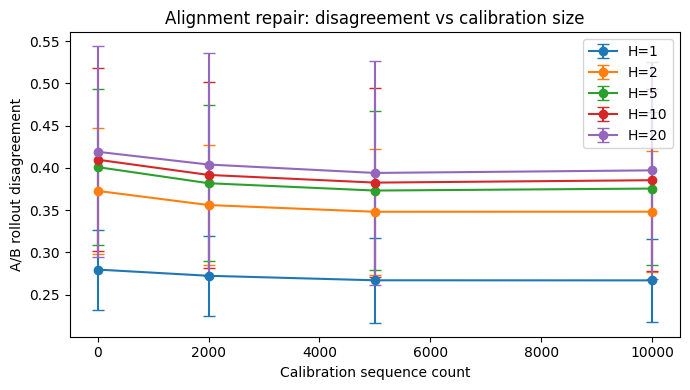

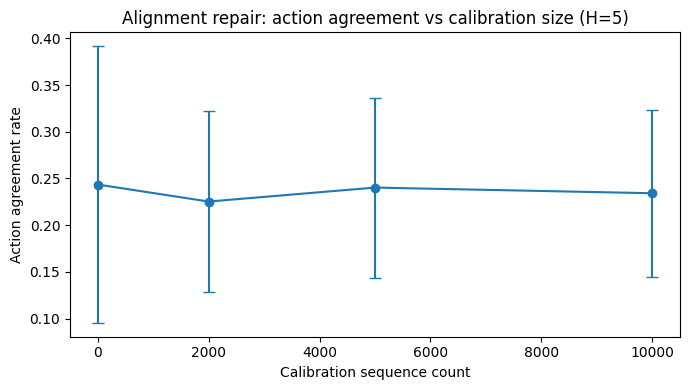

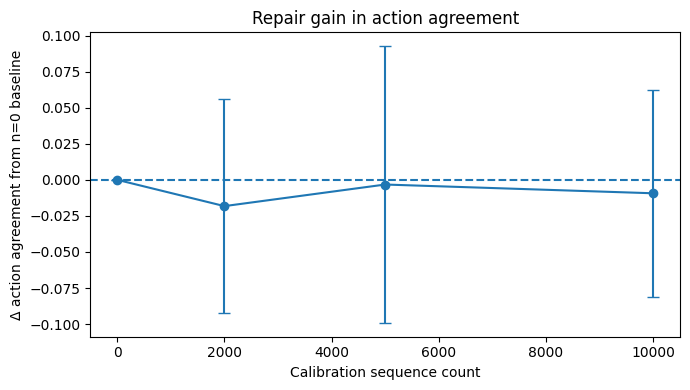

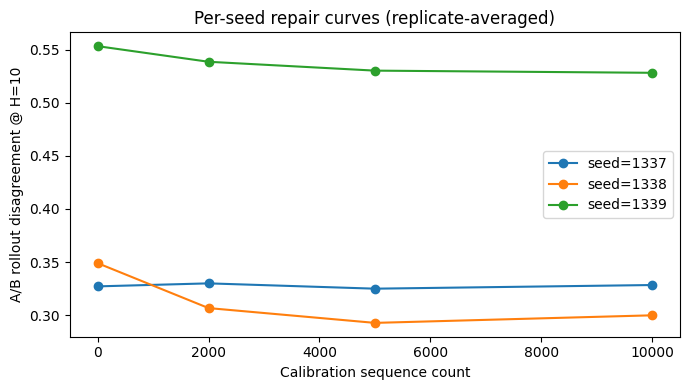

In [ ]:
# Cell 16: Plot 1 — rollout disagreement recovery

plt.figure(figsize=(7, 4))

for H in HORIZONS:
    xs = []
    means = []
    stds = []
    for n_calib in CALIB_SEQ_COUNTS:
        vals = [
            float(r["rollout_metrics_by_horizon"][str(H)]["AB_disagreement"])
            for r in repair_results["runs"]
            if int(r["calib_seq_count"]) == n_calib
        ]
        xs.append(n_calib)
        means.append(np.mean(vals))
        stds.append(np.std(vals, ddof=1) if len(vals) > 1 else 0.0)

    plt.errorbar(xs, means, yerr=stds, marker="o", capsize=4, label=f"H={H}")

plt.xlabel("Calibration sequence count")
plt.ylabel("A/B rollout disagreement")
plt.title("Alignment repair: disagreement vs calibration size")
plt.legend()
plt.tight_layout()
plt.show()



# Cell 17: Plot 2 — action agreement recovery

plt.figure(figsize=(7, 4))

xs = []
means = []
stds = []

for n_calib in CALIB_SEQ_COUNTS:
    vals = [
        float(r["action_metrics"]["action_agreement_rate"])
        for r in repair_results["runs"]
        if int(r["calib_seq_count"]) == n_calib
    ]
    xs.append(n_calib)
    means.append(np.mean(vals))
    stds.append(np.std(vals, ddof=1) if len(vals) > 1 else 0.0)

plt.errorbar(xs, means, yerr=stds, marker="o", capsize=4)
plt.xlabel("Calibration sequence count")
plt.ylabel("Action agreement rate")
plt.title(f"Alignment repair: action agreement vs calibration size (H={PLAN_HORIZON})")
plt.tight_layout()
plt.show()


# Cell 17b: Plot 2b — delta action agreement vs baseline

plt.figure(figsize=(7, 4))

xs = []
means = []
stds = []

for n_calib in CALIB_SEQ_COUNTS:
    deltas = []
    for seed in SEEDS:
        for replicate_id in range(CALIB_REPLICATES):
            base = [
                r for r in repair_results["runs"]
                if int(r["seed"]) == seed and int(r["calib_seq_count"]) == 0 and int(r["replicate_id"]) == replicate_id
            ][0]
            cur = [
                r for r in repair_results["runs"]
                if int(r["seed"]) == seed and int(r["calib_seq_count"]) == n_calib and int(r["replicate_id"]) == replicate_id
            ][0]

            base_agr = float(base["action_metrics"]["action_agreement_rate"])
            cur_agr = float(cur["action_metrics"]["action_agreement_rate"])
            deltas.append(cur_agr - base_agr)

    xs.append(n_calib)
    means.append(np.mean(deltas))
    stds.append(np.std(deltas, ddof=1) if len(deltas) > 1 else 0.0)

plt.errorbar(xs, means, yerr=stds, marker="o", capsize=4)
plt.axhline(0.0, linestyle="--")
plt.xlabel("Calibration sequence count")
plt.ylabel("Δ action agreement from n=0 baseline")
plt.title("Repair gain in action agreement")
plt.tight_layout()
plt.show()



# Cell 18: Plot 3 — H=10 disagreement per seed (replicate-averaged)

plt.figure(figsize=(7, 4))

for seed in SEEDS:
    xs = []
    ys = []
    for n_calib in CALIB_SEQ_COUNTS:
        vals = [
            float(r["rollout_metrics_by_horizon"]["10"]["AB_disagreement"])
            for r in repair_results["runs"]
            if int(r["seed"]) == seed and int(r["calib_seq_count"]) == n_calib
        ]
        xs.append(n_calib)
        ys.append(np.mean(vals))
    plt.plot(xs, ys, marker="o", label=f"seed={seed}")

plt.xlabel("Calibration sequence count")
plt.ylabel("A/B rollout disagreement @ H=10")
plt.title("Per-seed repair curves (replicate-averaged)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cell 19: Sanity check — inventory

expected = {
    (int(seed), int(n_calib), int(rep))
    for seed in SEEDS
    for n_calib in CALIB_SEQ_COUNTS
    for rep in range(CALIB_REPLICATES)
}
found = {
    (int(r["seed"]), int(r["calib_seq_count"]), int(r["replicate_id"]))
    for r in repair_results["runs"]
}

missing = expected - found
extra = found - expected

print("Missing:", missing)
print("Extra:", extra)

assert len(missing) == 0, f"Missing repair runs: {missing}"
assert len(extra) == 0, f"Unexpected repair runs: {extra}"
print("Inventory check passed.")

Missing: set()
Extra: set()
Inventory check passed.


In [ ]:
# Cell 20: Sanity check — numeric validity

def is_bad_number(x):
    return (x is None) or (isinstance(x, float) and (math.isnan(x) or math.isinf(x)))

bad = []

for run in repair_results["runs"]:
    seed = int(run["seed"])
    n_calib = int(run["calib_seq_count"])
    rep = int(run["replicate_id"])

    # Rollout metrics
    for H in HORIZONS:
        m = run["rollout_metrics_by_horizon"][str(H)]

        for key in ["A_rollout_mse", "B_rollout_mse", "AB_disagreement"]:
            v = float(m[key])
            if is_bad_number(v) or v < 0:
                bad.append((seed, n_calib, rep, H, key, v))

        if int(m["n"]) <= 0:
            bad.append((seed, n_calib, rep, H, "n", m["n"]))

    # Action metrics: rates must be in [0,1]
    am = run["action_metrics"]
    for key in [
        "action_agreement_rate",
        "A_actual_action_pick_rate",
        "B_actual_action_pick_rate",
    ]:
        v = float(am[key])
        if is_bad_number(v) or v < 0.0 or v > 1.0:
            bad.append((seed, n_calib, rep, key, v))

    # Confidence gaps must be finite and nonnegative
    for key in ["A_mean_confidence_gap", "B_mean_confidence_gap"]:
        v = float(am[key])
        if is_bad_number(v) or v < 0.0:
            bad.append((seed, n_calib, rep, key, v))

    # Best scores only need to be finite; they may be negative
    for key in ["A_mean_best_score", "B_mean_best_score"]:
        v = float(am[key])
        if is_bad_number(v):
            bad.append((seed, n_calib, rep, key, v))

    # Count must be positive
    if int(am["n"]) <= 0:
        bad.append((seed, n_calib, rep, "action_metrics.n", am["n"]))

if len(bad) == 0:
    print("Numeric sanity check passed.")
else:
    print("Found bad values:")
    for x in bad:
        print(x)
    raise ValueError("Numeric sanity check failed.")

Numeric sanity check passed.


In [ ]:
# Cell 20b: Sanity check — replicate coverage summary

print("Replicate coverage:")
for seed in SEEDS:
    for n_calib in CALIB_SEQ_COUNTS:
        reps = sorted([
            int(r["replicate_id"])
            for r in repair_results["runs"]
            if int(r["seed"]) == seed and int(r["calib_seq_count"]) == n_calib
        ])
        print(f"seed={seed} n={n_calib} | reps={reps}")

Replicate coverage:
seed=1337 n=0 | reps=[0, 1, 2]
seed=1337 n=2000 | reps=[0, 1, 2]
seed=1337 n=5000 | reps=[0, 1, 2]
seed=1337 n=10000 | reps=[0, 1, 2]
seed=1338 n=0 | reps=[0, 1, 2]
seed=1338 n=2000 | reps=[0, 1, 2]
seed=1338 n=5000 | reps=[0, 1, 2]
seed=1338 n=10000 | reps=[0, 1, 2]
seed=1339 n=0 | reps=[0, 1, 2]
seed=1339 n=2000 | reps=[0, 1, 2]
seed=1339 n=5000 | reps=[0, 1, 2]
seed=1339 n=10000 | reps=[0, 1, 2]
